# Appendix A: Deeper Explanation for Echoes

## Feedback for Fading Echoes

Feedback means taking the output of a system and feeding it back into the input. 

We do this in `echoes.sv` when we store the calculated output `data_in` back into our array `prev_samples`. This is because feedback allows us create multiple echoes that gradually fade over time.

The easiest way to understand this is to trace it with an example. 

**Example:**

Suppose the delay is 2 seconds.

---

**At 2 seconds:**  
Input = A  

$y[n] = A + 0$ 

(No delayed signal yet because we're at the start)

---

**At 4 seconds:**  
Input = B  

$y[n] = x[n] + \frac{1}{2} y[n-D]$

$= B + \frac{1}{2}A $

---

**At 6 seconds:**  
Input = C  

$y[n] = x[n] + \frac{1}{2} y[n-D]$ 

$= C + \frac{1}{2}(B + \frac{1}{2}A)$

$= C + \frac{1}{2}B + \frac{1}{4}A$ 


---

**At 8 seconds:**  
Input = E

$y[n] = x[n] + \frac{1}{2} y[n-D]$ 

$= E + \frac{1}{2}(C + \frac{1}{2}B + \frac{1}{4}A)$

$= E + \frac{1}{2}C + \frac{1}{4}B + \frac{1}{8}A$ 



You can see that because of feedback, $A$ gradually decreases and will eventually goes to zero. Without feedback, we would only get a single echo and not this gradual fade.

## Ring Buffers

The array we built in `echoes.sv` is called a ring buffer. A ring buffer is an array that wraps around in a circle (or a "ring"). When the position reaches the end of the buffer, it wraps back to the beginning.

We use a ring buffer because one full revolution through the buffer corresponds to the delay time between echoes. This is how the delay is created. We also cannot simply count up to $D$ and store a single sample, because echoes need to be continuous over time rather than occurring just once.

The easiest way to understand this is to trace it with an example. 

**Example:**

Suppose the delay is 4 seconds and we can track index 0. 

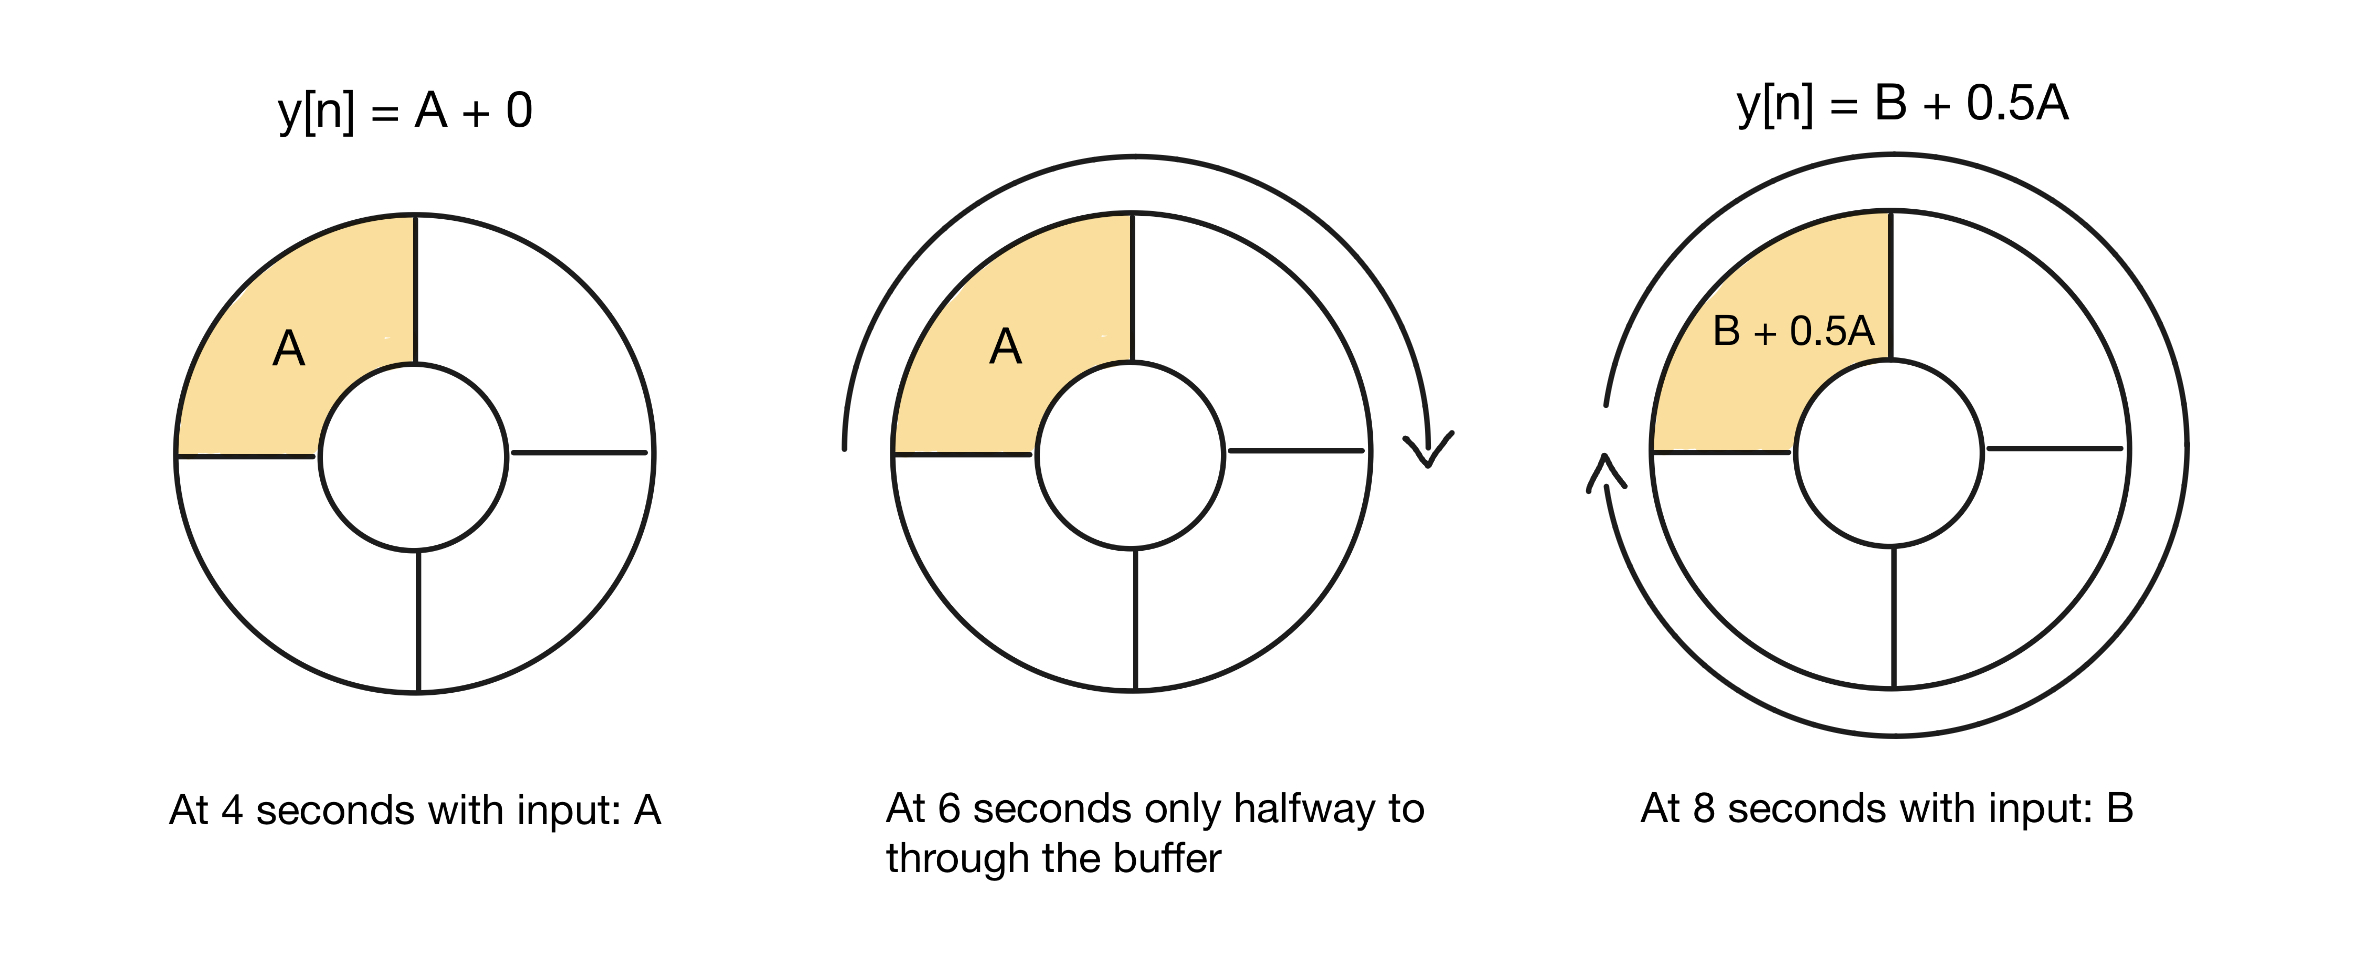

You can notice that the time for one full revolution through the buffer is the delay time $D$. In this case, it takes 4 samples to return to the same position, so the delay is 4 samples which corresponds to 4 seconds.